# Task 2 — Exploratory Data Analysis

The brief poses eight questions; each section below answers one, with a chart and a
short interpretation. Charts are saved to `../outputs/` as PNGs for the report.

One caveat up front, and it applies to this whole notebook: the values are synthetic.
Utility names and town locations are real, but capacities, ages, connections and
statuses come from a seeded random generator. Findings below are statements about
this dataset, not about Ghana's actual grid.

In [1]:
import sys

sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import griddata

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

data, _ = griddata.clean(griddata.load_raw())
utilities, substations, lines = data["utilities"], data["substations"], data["lines"]
master = griddata.build_master(data)

OUT = "../outputs"

## Q1 — Which regions have the greatest number of substations?

Region
Greater Accra           6
Ashanti                 5
Western                 4
Central                 4
Eastern                 4
Volta                   4
Bono                    3
Northern                3
Upper East              2
Upper West              1
Burkina Faso border     1
Cote d'Ivoire border    1
Togo border             1
Togo                    1
Benin                   1
Cote d'Ivoire           1
Burkina Faso            1
Guinea                  1
Name: count, dtype: int64

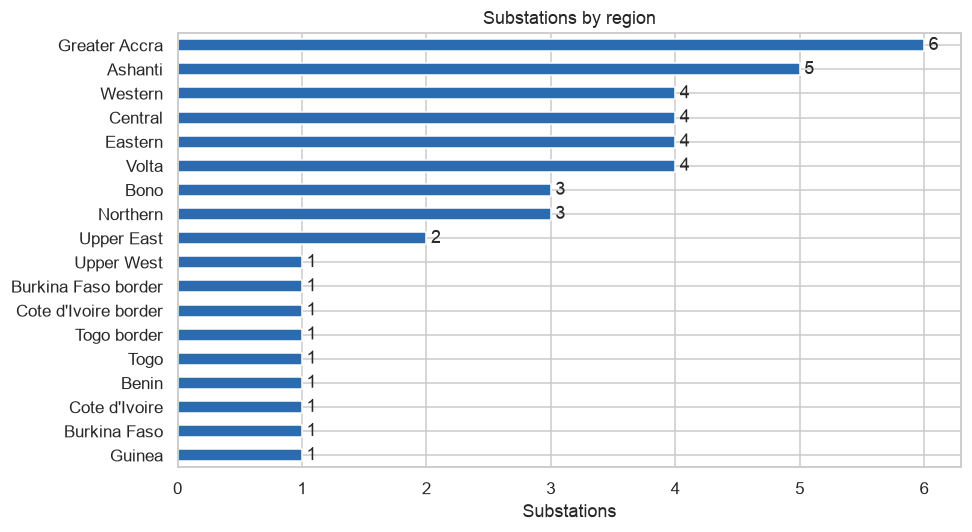

In [2]:
region_counts = substations["Region"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
region_counts.plot(kind="barh", ax=ax, color="#2b6cb0")
ax.invert_yaxis()
ax.set_xlabel("Substations")
ax.set_ylabel("")
ax.set_title("Substations by region")
ax.bar_label(ax.containers[0], padding=3)
fig.tight_layout()
fig.savefig(f"{OUT}/q1_substations_by_region.png", bbox_inches="tight")
region_counts

Greater Accra leads with 6, which tracks with it being the capital region — the
generator seeds it with the most locations. The single-substation "regions" at the
bottom (Togo, Benin, Guinea etc.) are the cross-border WAPP interconnection points,
which the dataset stores in the Region column by bordering country. Upper West
genuinely has one substation (Wa) — worth remembering for the coverage discussion.

## Q2 — Which voltage levels are most common?

Voltage (kV)
11      9
33      6
69      8
161    11
330    10
Name: count, dtype: int64

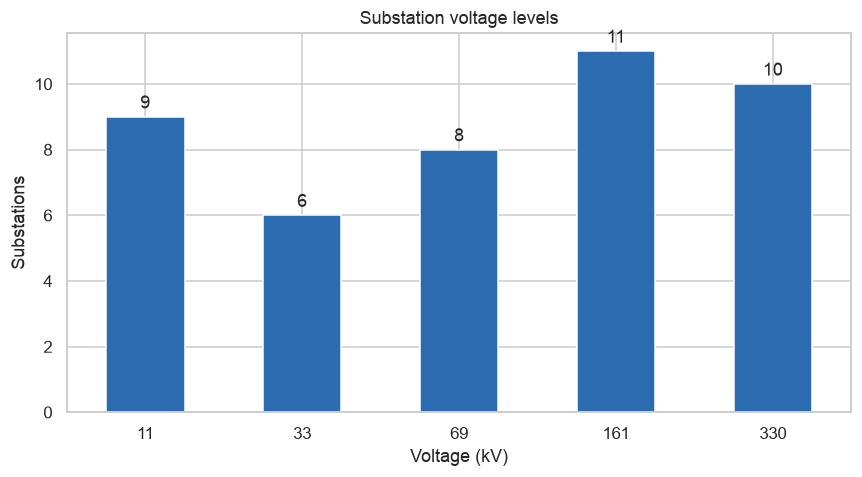

In [3]:
voltage_counts = substations["Voltage (kV)"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
voltage_counts.plot(kind="bar", ax=ax, color="#2b6cb0")
ax.set_xlabel("Voltage (kV)")
ax.set_ylabel("Substations")
ax.set_title("Substation voltage levels")
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(f"{OUT}/q2_voltage_levels.png", bbox_inches="tight")
voltage_counts

The Ghanaian substations are spread roughly evenly across the five standard levels
(11/33/69/161/330 kV) because the generator picks uniformly. The cross-border hubs
are exclusively 161/330 kV — correct behaviour for international interconnectors,
which run at transmission voltage. In a real register we'd expect far more 11/33 kV
distribution substations than transmission ones; the flat distribution is a
limitation of the synthetic data worth stating in the report.

## Q3 — Which utility operates the greatest number of lines?

,Code,Utility Name,Lines
0,GRD,Ghana Grid Company,24
1,NED,Northern Electricity Distribution Company,14
2,ECG,Electricity Company of Ghana,10
3,CEB,Communaute Electrique du Benin,3
4,CIE,Compagnie Ivoirienne d'Electricite,2
5,SNB,Sonabel,2


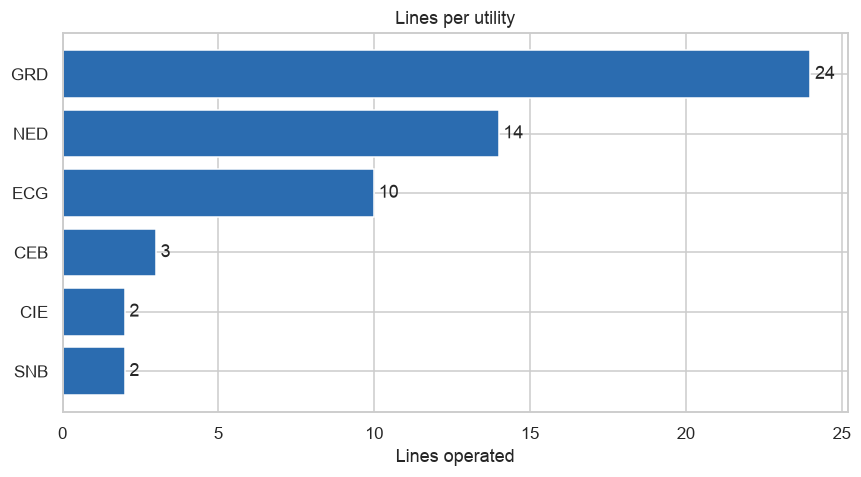

In [4]:
lines_per_utility = (
    master.groupby(["Code", "Utility Name"], observed=True)
    .size()
    .sort_values(ascending=False)
    .rename("Lines")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(lines_per_utility["Code"], lines_per_utility["Lines"], color="#2b6cb0")
ax.invert_yaxis()
ax.set_xlabel("Lines operated")
ax.set_title("Lines per utility")
ax.bar_label(ax.containers[0], padding=3)
fig.tight_layout()
fig.savefig(f"{OUT}/q3_lines_per_utility.png", bbox_inches="tight")
lines_per_utility

GRIDCo (GRD) comes out on top, which is what you'd want from a structurally sensible
dataset: GRIDCo is the transmission operator, and the generator gives it every
inter-regional backbone line on top of a share of the regional ones. ECG and NEDCo
split the remaining distribution lines. The utilities with zero lines (VRA, EPC —
generation companies; and the never-referenced foreign distributors) exist in
`utilities.csv` but own nothing in `lines.csv` — a good example of why we validate
foreign keys in both directions rather than assuming every parent row has children.

## Q4 — What is the distribution of substation capacities?

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Bulk Supply Point,8.0,199.5,126.2,57.9,89.9,179.5,298.6,389.2
Distribution,15.0,33.4,16.8,6.4,18.9,37.4,45.8,58.8
Transmission,21.0,230.9,135.6,25.2,146.0,221.4,325.9,487.6


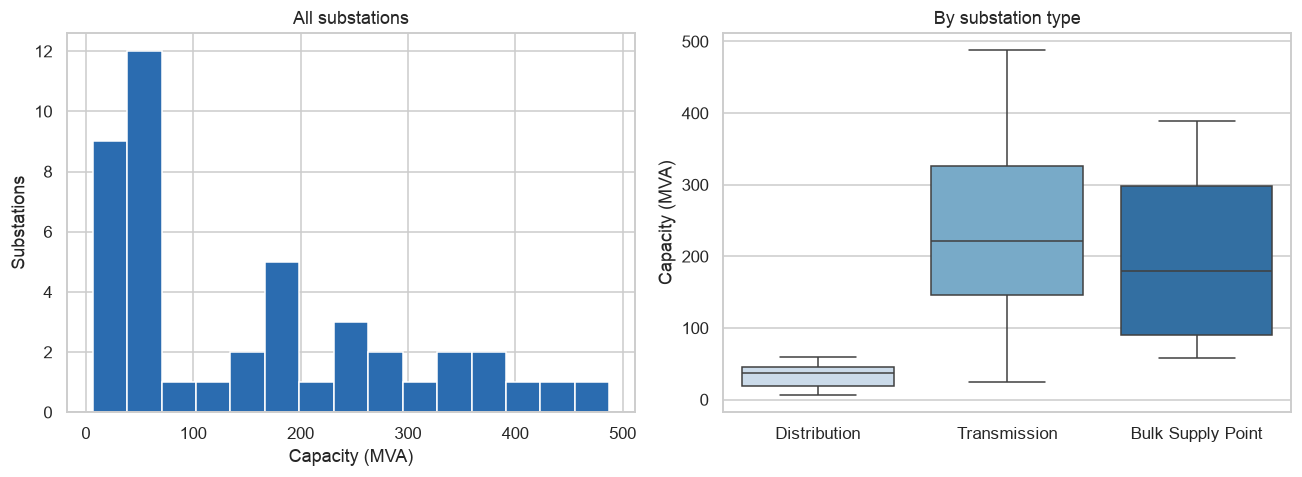

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(substations["Capacity (MVA)"], bins=15, color="#2b6cb0", edgecolor="white")
axes[0].set_xlabel("Capacity (MVA)")
axes[0].set_ylabel("Substations")
axes[0].set_title("All substations")

sns.boxplot(data=substations, x="Type", y="Capacity (MVA)", hue="Type", ax=axes[1],
            palette="Blues", legend=False)
axes[1].set_title("By substation type")
axes[1].set_xlabel("")

fig.tight_layout()
fig.savefig(f"{OUT}/q4_capacity_distribution.png", bbox_inches="tight")
substations.groupby("Type", observed=True)["Capacity (MVA)"].describe().round(1)

Strongly right-skewed: many small distribution substations under 60 MVA, a tail of
large transmission assets up to ~500 MVA. The generator draws distribution capacity
from 5–60 MVA and everything else from 15–400 (borders 100–500), and the split shows
cleanly in the box plot. Practical consequence: **mean capacity is a misleading
summary for this network** — median per type is the honest number, and that's what
the report quotes.

## Q5 — Which regions contain the oldest infrastructure?

,min,median,max,count
Region,,,,
Upper West,1977,1977.0,1977,1
Northern,1969,1978.0,2015,3
Upper East,1971,1981.5,1992,2
Burkina Faso,1983,1983.0,1983,1
Cote d'Ivoire border,1984,1984.0,1984,1
Western,1967,1987.0,2010,4
Burkina Faso border,1991,1991.0,1991,1
Benin,1995,1995.0,1995,1
Central,1970,1996.0,2003,4


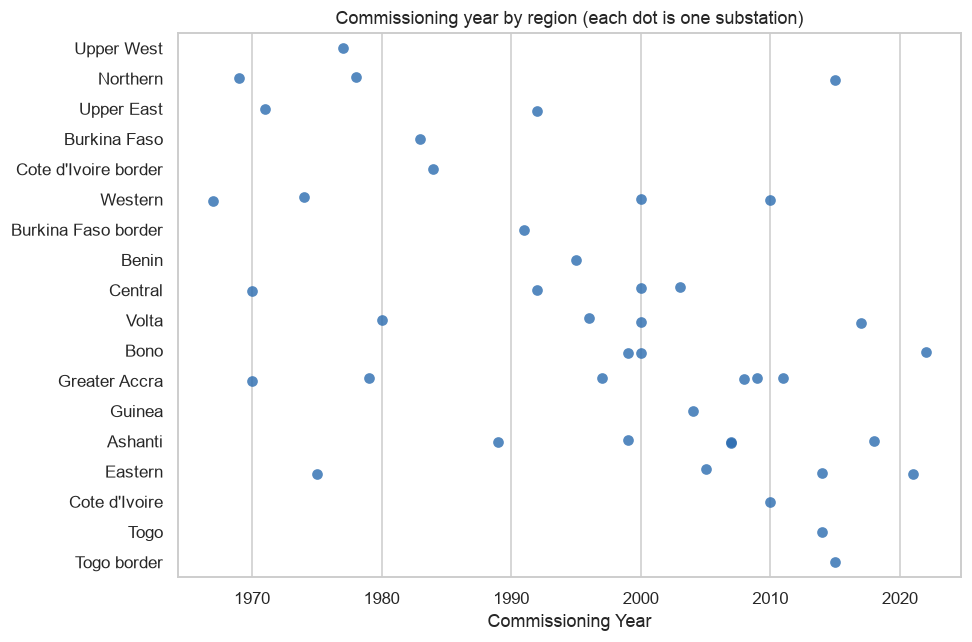

In [6]:
age = (
    substations.groupby("Region", observed=True)["Commissioning Year"]
    .agg(["min", "median", "max", "count"])
    .sort_values("median")
)

fig, ax = plt.subplots(figsize=(9, 6))
order = age.index
sns.stripplot(data=substations, y="Region", x="Commissioning Year", order=order,
              ax=ax, color="#2b6cb0", size=7, alpha=0.8)
ax.set_title("Commissioning year by region (each dot is one substation)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(f"{OUT}/q5_age_by_region.png", bbox_inches="tight")
age

A strip plot rather than a bar of averages, because several regions have two or three
substations and an average of three numbers hides more than it shows. The oldest
individual assets sit in the 1960s–70s. With ~4 substations per region drawn from a
uniform 1965–2023 range, regional differences in median age here are noise, not
signal — the honest reading is "asset age varies widely *within* regions", and the
per-asset view is what a maintenance planner would want anyway.

## Q6 — What proportion of lines are active or under maintenance?

,Source Substation,Destination Substation,Region_src,Region_dst,Voltage (kV),Code
7,Mallam Substation,Aboadze Junction Substation,Greater Accra,Greater Accra,161,GRD
22,Cape Coast Substation,Kasoa Substation,Central,Central,11,ECG


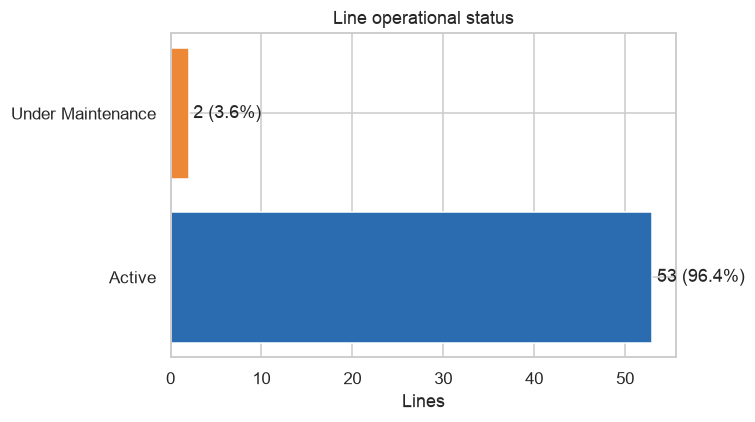

In [7]:
status_counts = lines["Status"].value_counts()
pct = (status_counts / len(lines) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(status_counts.index, status_counts.values, color=["#2b6cb0", "#ed8936"])
ax.set_xlabel("Lines")
ax.set_title("Line operational status")
for i, (n, p) in enumerate(zip(status_counts.values, pct.values)):
    ax.text(n + 0.5, i, f"{n} ({p}%)", va="center")
fig.tight_layout()
fig.savefig(f"{OUT}/q6_line_status.png", bbox_inches="tight")

maint = master[master["Status"] == "Under Maintenance"]
maint[["Source Substation", "Destination Substation", "Region_src", "Region_dst", "Voltage (kV)", "Code"]]

53 of 55 lines active (96.4%), two under maintenance — both intra-regional
distribution lines, so neither takes out a backbone corridor. Substation status is
similar: 43 of 44 active, with only Axim inactive. These numbers matter later:
the reliability analysis in the BI notebook asks whether maintenance work is
concentrated anywhere, and with n=2 the honest answer is that no pattern can be
claimed either way.

## Q7 — Which substations have the greatest number of connections?

Mallam Substation            5
Kumasi Central Substation    5
Cape Coast Substation        5
Achimota Substation          4
Tema Substation              4
Legon Substation             4
Takoradi Substation          4
Koforidua Substation         4
Ho Substation                4
Bolgatanga Substation        4
Name: Connections, dtype: int64

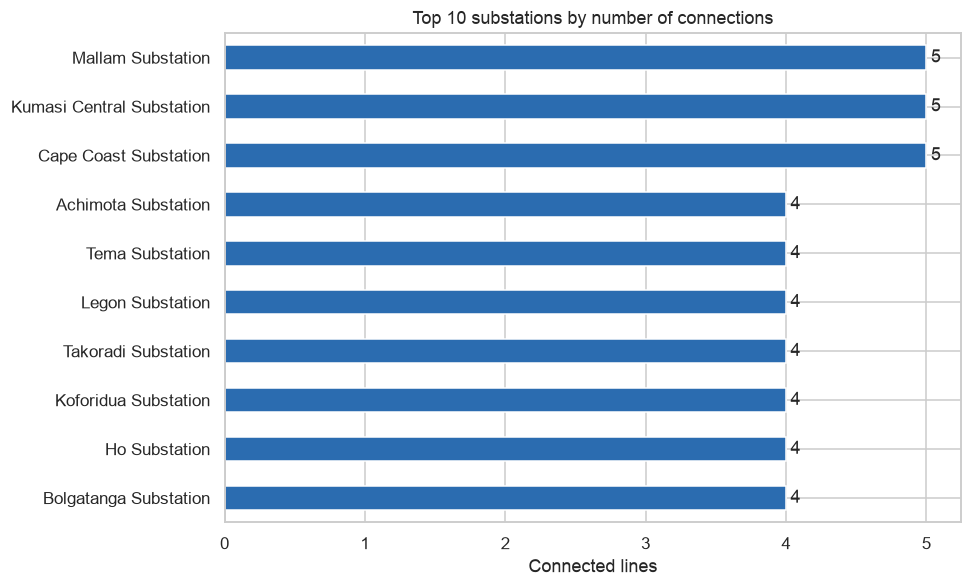

In [8]:
# Count both endpoints: a line touches two substations, and "connections" means
# connections, not "times listed as source". Counting only the source column would
# understate every substation that mostly appears as a destination.
endpoint_counts = (
    pd.concat([lines["Source Substation"], lines["Destination Substation"]])
    .value_counts()
    .rename("Connections")
)

fig, ax = plt.subplots(figsize=(9, 5.5))
endpoint_counts.head(10).plot(kind="barh", ax=ax, color="#2b6cb0")
ax.invert_yaxis()
ax.set_xlabel("Connected lines")
ax.set_title("Top 10 substations by number of connections")
ax.bar_label(ax.containers[0], padding=3)
fig.tight_layout()
fig.savefig(f"{OUT}/q7_most_connected.png", bbox_inches="tight")
endpoint_counts.head(10)

Mallam, Kumasi Central and Cape Coast tie at 5 connections each. This is the
DataFrame-side preview of the graph-theoretic degree analysis in notebook 04 — the
numbers there must agree with these (and do), which is a useful cross-check that the
graph was built correctly from the same data.

## Q8 — How are high-capacity substations distributed geographically?

,Short Name,Region,Voltage (kV),Capacity (MVA),Type
40,Cotonou Transmission Hub,Benin,161,487.6,Transmission
42,Bobo-Dioulasso Hub,Burkina Faso,161,445.9,Transmission
38,Aflao Border Station,Togo border,330,423.2,Transmission
21,Nkawkaw,Eastern,69,389.2,Bulk Supply Point
23,Ho,Volta,330,382.1,Transmission
7,Ejisu,Ashanti,330,355.9,Transmission
22,Suhum,Eastern,69,339.0,Bulk Supply Point
33,Bolgatanga,Upper East,161,325.9,Transmission


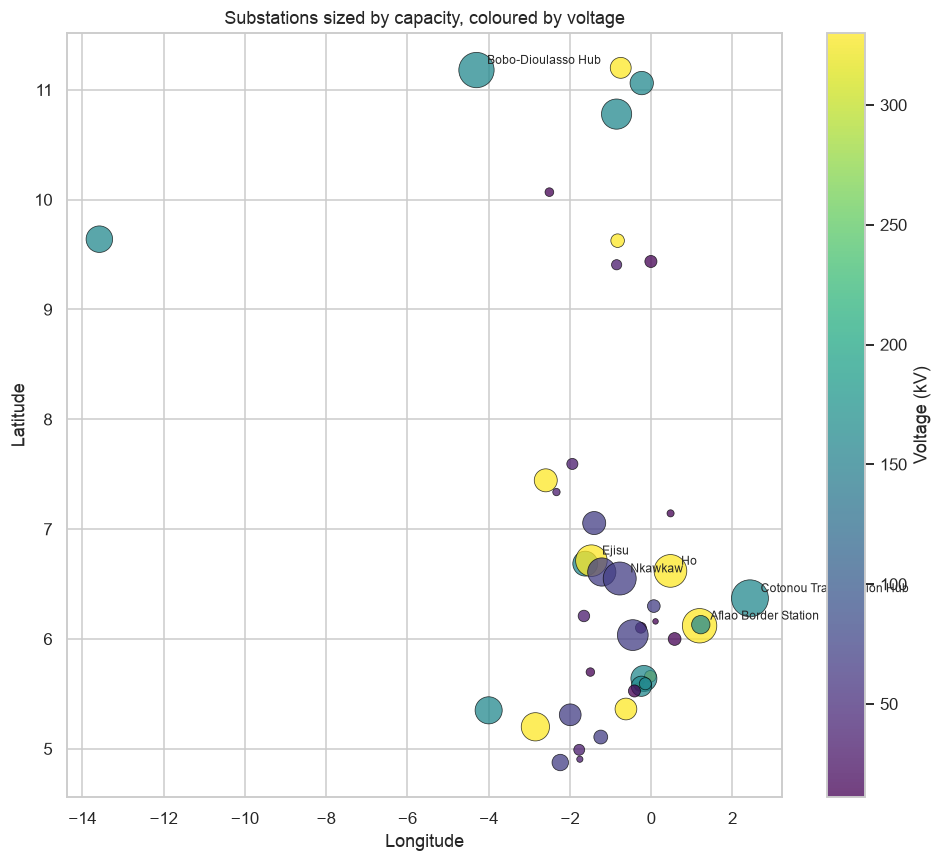

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    substations["Longitude"], substations["Latitude"],
    s=substations["Capacity (MVA)"] * 1.2,
    c=substations["Voltage (kV)"], cmap="viridis", alpha=0.75, edgecolor="black", linewidth=0.5,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Substations sized by capacity, coloured by voltage")
fig.colorbar(scatter, ax=ax, label="Voltage (kV)")

# Label the biggest few so the plot is readable without hovering.
for _, row in substations.nlargest(6, "Capacity (MVA)").iterrows():
    ax.annotate(row["Short Name"], (row["Longitude"], row["Latitude"]),
                textcoords="offset points", xytext=(7, 4), fontsize=8)

fig.tight_layout()
fig.savefig(f"{OUT}/q8_capacity_map.png", bbox_inches="tight")
substations.nlargest(8, "Capacity (MVA)")[["Short Name", "Region", "Voltage (kV)", "Capacity (MVA)", "Type"]]

The largest capacities cluster at the borders — the WAPP interconnection hubs (drawn
from the generator's 100–500 MVA range) — plus scattered large transmission sites
inland. The far-western outlier is Conakry (Guinea), which Q1's isolated-node finding
already flagged as unconnected. A proper basemap version of this plot is in the
geographic notebook (05) using Folium; this scatter is the quick matplotlib view.

## Where this leaves us

Initial hypotheses for the network analysis (notebook 04):

1. **Mallam / Kumasi Central / Cape Coast will top degree centrality** (Q7), but
   *betweenness* may rank differently — the backbone chain runs hub-to-hub, so a
   mid-chain hub like Kumasi Central should score high betweenness even where degree
   ties.
2. **The network should survive single-node removal** (the brief's own sample run
   says so), but removing a *backbone* node rather than the highest-degree node may
   fragment it — worth testing both.
3. **Cross-border links are thin**: a handful of lines carry all international
   connectivity, so bridge detection should flag them.

Open questions the merged data can answer (notebook 03): line-length by voltage tier,
utility footprints per region, and which region pairs the backbone actually joins.